# Axon Break Detection — Improved Pipeline

Key fixes over `best_method.ipynb`:

| Change | Why |
|--------|-----|
| **No morphological closing** in Frangi preprocessing | Closing was bridging the gaps we want to detect |
| **min_component_size = 15** (was 30) | Short stubs at break sites were being discarded |
| **endpoint_rate** metric added | Each break = 2 new endpoints → 2× more sensitive than frag_rate |
| **gap_bridge_rate** metric added | Counts fragments that reconnect at a given dilation radius = direct break count |
| **show_detected_breaks** visualization | Draws break pairs on original image with skeleton overlay |

In [1]:
from pylibCZIrw import czi as pyczi
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
from skimage.morphology import skeletonize, disk, dilation
from skimage.filters import frangi, gaussian, threshold_otsu
from scipy import ndimage
from scipy.spatial import cKDTree
from skimage.measure import label
from scipy.stats import kruskal
from itertools import combinations
import numpy as np

In [2]:
# ── I/O helpers ───────────────────────────────────────────────────────────────

def _load(path, channel=0):
    """Max-Z projection over all Z planes at T=0, channel 0 (tubulin)."""
    with pyczi.open_czi(path) as cz:
        n_z = cz.total_bounding_box['Z'][1]
        planes = [np.squeeze(cz.read(plane={'C': channel, 'Z': z, 'T': 0}))
                  for z in range(n_z)]
    return np.stack(planes).max(axis=0)

def _norm(img):
    f = img.astype(float)
    return (f - f.min()) / (f.max() - f.min() + 1e-8)

def _n_zplanes(path):
    with pyczi.open_czi(path) as cz:
        return cz.total_bounding_box['Z'][1]


# ── Skeleton helpers ──────────────────────────────────────────────────────────

def find_skeleton_endpoints(skeleton):
    kernel = np.ones((3, 3), dtype=np.uint8)
    kernel[1, 1] = 0
    nc = ndimage.convolve(skeleton.astype(np.uint8), kernel, mode='constant', cval=0)
    return np.argwhere((skeleton > 0) & (nc == 1))

def filter_small_components(skeleton, min_size=15):
    labeled = label(skeleton, connectivity=2)
    sizes   = np.bincount(labeled.ravel())
    keep    = np.where(sizes >= min_size)[0]
    keep    = keep[keep != 0]
    return np.isin(labeled, keep)


# ── Frangi preprocessing — NO morphological closing ──────────────────────────

def preprocess_frangi(img, sigmas=(1, 2, 3, 4, 5), beta=0.5):
    """
    Frangi vesselness filter without morphological closing.
    Closing filled in the small dark gaps that are break sites — removed here.
    """
    img_smooth = gaussian(_norm(img), sigma=1)
    tube_map   = frangi(img_smooth, sigmas=sigmas, beta=beta, black_ridges=False)
    binary     = tube_map > threshold_otsu(tube_map)   # no closing
    return binary, tube_map

def _make_skeleton(img, sigmas=(1, 2, 3, 4, 5)):
    binary, tube_map = preprocess_frangi(img, sigmas=sigmas)
    return skeletonize(binary), binary, tube_map

In [3]:
# ── Enhanced metrics ──────────────────────────────────────────────────────────

def compute_metrics(skeleton, min_component_size=15, gap_radius=30):
    """
    skel_length      : total skeleton pixels
    n_components     : connected fragments after removing tiny spurs
    frag_rate        : n_components / skel_length × 1000
    continuity       : skel_length / n_components  (mean fragment length px)
    short_frac       : fraction of fragments shorter than 50 px
    endpoint_rate    : n_endpoints / skel_length × 1000
                       Each break produces 2 endpoints vs. 1 new component →
                       endpoint_rate is ~2× more sensitive to breaks than frag_rate.
    gap_bridges      : number of components that merge when skeleton is dilated by gap_radius
    gap_bridge_rate  : gap_bridges / skel_length × 1000
                       Directly counts closeable breaks, independent of endpoint matching.
    """
    skel_clean  = filter_small_components(skeleton, min_size=min_component_size).astype(bool)
    lbl         = label(skel_clean, connectivity=2)
    n_comp      = int(lbl.max())
    skel_length = int(skel_clean.sum())
    if n_comp == 0 or skel_length == 0:
        return dict(skel_length=0, n_components=0, frag_rate=0., continuity=0.,
                    short_frac=0., endpoint_rate=0., gap_bridges=0, gap_bridge_rate=0.)
    sizes           = np.bincount(lbl.ravel())[1:]
    frag_rate       = n_comp / skel_length * 1000
    continuity      = skel_length / n_comp
    short_frac      = float((sizes < 50).sum() / n_comp)
    endpoints       = find_skeleton_endpoints(skel_clean)
    endpoint_rate   = len(endpoints) / skel_length * 1000
    n_after         = int(label(dilation(skel_clean, disk(gap_radius)), connectivity=2).max())
    gap_bridges     = max(0, n_comp - n_after)
    gap_bridge_rate = gap_bridges / skel_length * 1000
    return dict(skel_length=skel_length, n_components=n_comp, frag_rate=frag_rate,
                continuity=continuity, short_frac=short_frac,
                endpoint_rate=endpoint_rate, gap_bridges=gap_bridges,
                gap_bridge_rate=gap_bridge_rate)

In [4]:
# ── Break detection — direction + gap clarity filters ────────────────────────

def _compute_tangent(skel_pts, ep, window=15):
    dists = np.linalg.norm(skel_pts - ep, axis=1)
    nearby = skel_pts[dists <= window]
    if len(nearby) < 3:
        return None
    centroid = nearby.mean(axis=0)
    vec = np.array(ep, dtype=float) - centroid
    n = np.linalg.norm(vec)
    return vec / n if n > 1e-8 else None

def _gap_is_clear(binary_mask, pt1, pt2, n_samples=30, border_frac=0.15, max_overlap=0.10):
    rs = np.linspace(pt1[0], pt2[0], n_samples)
    cs = np.linspace(pt1[1], pt2[1], n_samples)
    skip = max(1, int(n_samples * border_frac))
    rs = np.round(rs[skip:-skip]).astype(int)
    cs = np.round(cs[skip:-skip]).astype(int)
    if len(rs) == 0:
        return True
    rs = np.clip(rs, 0, binary_mask.shape[0] - 1)
    cs = np.clip(cs, 0, binary_mask.shape[1] - 1)
    return float(binary_mask[rs, cs].mean()) <= max_overlap

def find_broken_lines(skeleton, binary_mask=None, min_gap=10, max_gap=80,
                      min_component_size=15, angle_threshold=40,
                      max_gap_overlap=0.10, tangent_window=15):
    """
    Find axon break pairs using two filters:
      1. Direction: both endpoint tangents must be aligned (same axon)
      2. Gap clarity: the path between them must be dark (no crossing axon)
    """
    skeleton   = filter_small_components(skeleton, min_size=min_component_size).astype(bool)
    endpoints  = find_skeleton_endpoints(skeleton)
    if len(endpoints) < 2:
        return [], endpoints
    skel_pts   = np.argwhere(skeleton)
    comp_map   = label(skeleton, connectivity=2)
    ep_labels  = np.array([comp_map[r, c] for r, c in endpoints])
    cos_thresh = np.cos(np.radians(angle_threshold))
    tree       = cKDTree(endpoints)
    candidates = []
    for i, j in tree.query_pairs(r=max_gap):
        if ep_labels[i] == ep_labels[j]:
            continue
        dist = float(np.linalg.norm(endpoints[i] - endpoints[j]))
        if dist < min_gap:
            continue
        gap_vec = (endpoints[j].astype(float) - endpoints[i]) / dist
        ti = _compute_tangent(skel_pts, endpoints[i], window=tangent_window)
        tj = _compute_tangent(skel_pts, endpoints[j], window=tangent_window)
        if ti is not None and tj is not None:
            if np.dot(ti, gap_vec) < cos_thresh:   continue
            if np.dot(-tj, gap_vec) < cos_thresh:  continue
            if abs(np.dot(ti, tj)) < cos_thresh:   continue
        if binary_mask is not None:
            if not _gap_is_clear(binary_mask, tuple(endpoints[i]), tuple(endpoints[j]),
                                 max_overlap=max_gap_overlap):
                continue
        candidates.append((dist, i, j))
    candidates.sort()
    used = set(); breaks = []
    for dist, i, j in candidates:
        if i not in used and j not in used:
            used.update([i, j])
            breaks.append({'pt1': tuple(endpoints[i]),
                           'pt2': tuple(endpoints[j]),
                           'distance': dist})
    return breaks, endpoints

In [5]:
# ── Visualisation functions ───────────────────────────────────────────────────

def show_segmentation(directory, sigmas=(1, 2, 3, 4, 5)):
    """3 panels: original | Frangi tubeness | binary mask (no closing)."""
    files = sorted(f for f in os.listdir(directory) if f.endswith('.czi'))
    if not files: return
    n = len(files)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = axes[np.newaxis, :]
    for i, fname in enumerate(files):
        fpath = os.path.join(directory, fname)
        img   = _load(fpath)
        binary, tube_map = preprocess_frangi(img, sigmas=sigmas)
        img_norm  = _norm(img)
        mask_rgba = np.zeros((*binary.shape, 4))
        mask_rgba[binary] = [0., 1., 0., 0.5]
        ax0, ax1, ax2 = axes[i]
        ax0.imshow(img_norm, cmap='gray'); ax0.axis('off')
        ax0.set_title(f"{fname}  ({_n_zplanes(fpath)} Z)", fontsize=9)
        ax1.imshow(tube_map, cmap='hot'); ax1.axis('off')
        ax1.set_title(f"Frangi tubeness  sigmas={sigmas}", fontsize=9)
        ax2.imshow(img_norm, cmap='gray'); ax2.axis('off')
        ax2.imshow(mask_rgba)
        ax2.set_title(f"Binary mask (no closing)  {binary.mean()*100:.1f}% px", fontsize=9)
    cond = os.path.basename(directory.rstrip('/'))
    fig.suptitle(cond, fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()


def print_metrics(directory, min_component_size=15, gap_radius=30, sigmas=(1, 2, 3, 4, 5)):
    files = sorted(f for f in os.listdir(directory) if f.endswith('.czi'))
    if not files: return
    print(f"\n{'─'*105}")
    print(f"{'File':<15} {'Z':>3} {'Skel px':>9} {'Frags':>6} "
          f"{'Frag/1k':>8} {'EP/1k':>7} {'GapBr/1k':>9} {'Continuity':>12} {'Short%':>7}")
    print(f"{'─'*105}")
    for fname in files:
        fpath = os.path.join(directory, fname)
        img   = _load(fpath)
        skel, _, _ = _make_skeleton(img, sigmas)
        m = compute_metrics(skel, min_component_size, gap_radius)
        print(f"{fname:<15} {_n_zplanes(fpath):>3} {m['skel_length']:>9,} {m['n_components']:>6} "
              f"{m['frag_rate']:>8.2f} {m['endpoint_rate']:>7.2f} "
              f"{m['gap_bridge_rate']:>9.2f} {m['continuity']:>12.1f} "
              f"{m['short_frac']*100:>6.1f}%")


def show_fragment_map(directory, min_component_size=15, short_thresh=60, long_thresh=200,
                      sigmas=(1, 2, 3, 4, 5), gap_radius=30):
    """Colour each fragment by length: red=short/broken, blue=long/intact."""
    files = sorted(f for f in os.listdir(directory) if f.endswith('.czi'))
    if not files: return
    n = len(files)
    cols = min(3, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    axes = np.array(axes, dtype=object).ravel()
    for i, fname in enumerate(files):
        img  = _load(os.path.join(directory, fname))
        skel, _, _ = _make_skeleton(img, sigmas)
        m    = compute_metrics(skel, min_component_size, gap_radius)
        sc   = filter_small_components(skel, min_size=min_component_size).astype(bool)
        lbl  = label(sc, connectivity=2)
        szs  = np.bincount(lbl.ravel())
        ov   = np.zeros((*sc.shape, 4), dtype=float)
        for cid in range(1, lbl.max() + 1):
            t = np.clip((szs[cid] - short_thresh) / (long_thresh - short_thresh), 0, 1)
            ov[lbl == cid] = [1 - t, 1 - abs(2*t - 1), t, 0.85]
        ax = axes[i]
        ax.imshow(_norm(img), cmap='gray', interpolation='nearest')
        ax.imshow(ov, interpolation='nearest')
        ax.axis('off')
        ax.set_title(
            f"{fname}\n"
            f"Frags:{m['n_components']}  EP/1k:{m['endpoint_rate']:.1f}  "
            f"GapBr/1k:{m['gap_bridge_rate']:.1f}  Cont:{m['continuity']:.0f}px",
            fontsize=7)
    handles = [Patch(facecolor='red',   label=f'Short < {short_thresh}px'),
               Patch(facecolor='green', label='Intermediate'),
               Patch(facecolor='blue',  label=f'Long > {long_thresh}px')]
    axes[0].legend(handles=handles, loc='upper right', fontsize=7, framealpha=0.7)
    for j in range(n, len(axes)): axes[j].set_visible(False)
    cond = os.path.basename(directory.rstrip('/'))
    fig.suptitle(f"{cond} — fragment map", fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()


def show_detected_breaks(directory, min_component_size=15, sigmas=(1, 2, 3, 4, 5),
                         min_gap=10, max_gap=80, angle_threshold=40,
                         max_gap_overlap=0.10, tangent_window=15):
    """
    Draw detected break pairs on the original image.
    Cyan overlay = skeleton  |  red circles = break endpoints  |  yellow dashes = gap.
    """
    files = sorted(f for f in os.listdir(directory) if f.endswith('.czi'))
    n = len(files)
    if n == 0: return
    cols = min(3, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    axes = np.array(axes, dtype=object).ravel()
    for i, fname in enumerate(files):
        img  = _load(os.path.join(directory, fname))
        skel, binary, _ = _make_skeleton(img, sigmas)
        breaks, eps = find_broken_lines(
            skel, binary_mask=binary,
            min_gap=min_gap, max_gap=max_gap,
            min_component_size=min_component_size,
            angle_threshold=angle_threshold,
            max_gap_overlap=max_gap_overlap,
            tangent_window=tangent_window)
        sc = filter_small_components(skel, min_size=min_component_size).astype(bool)
        ov = np.zeros((*sc.shape, 4), dtype=float)
        ov[sc] = [0., 0.9, 0.9, 0.6]
        ax = axes[i]
        ax.imshow(_norm(img), cmap='gray', interpolation='nearest')
        ax.imshow(ov, interpolation='nearest')
        for b in breaks:
            (r1, c1), (r2, c2) = b['pt1'], b['pt2']
            ax.plot([c1, c2], [r1, r2], '--', color='yellow', lw=1.5, alpha=0.85, zorder=4)
            for rc in [(r1, c1), (r2, c2)]:
                ax.plot(rc[1], rc[0], 'o', color='red', markersize=8,
                        markerfacecolor='none', markeredgewidth=1.5, zorder=5)
        ax.set_title(f"{fname}\n{len(breaks)} breaks detected  |  {len(eps)} endpoints",
                     fontsize=8)
        ax.axis('off')
    for j in range(n, len(axes)): axes[j].set_visible(False)
    cond = os.path.basename(directory.rstrip('/'))
    fig.suptitle(f"{cond} — detected breaks  (gap {min_gap}–{max_gap}px)",
                 fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()


def show_detected_breaks_zoom(filepath, condition=None, n_show=12, zoom_px=80,
                              min_component_size=15, sigmas=(1, 2, 3, 4, 5),
                              min_gap=10, max_gap=80, angle_threshold=40,
                              max_gap_overlap=0.10, tangent_window=15):
    """
    Zoom gallery around detected break sites for presentation.
    Each tile is centred on one break gap — cyan skeleton, yellow gap line, red endpoint circles.
    """
    img  = _load(filepath)
    skel, binary, _ = _make_skeleton(img, sigmas)
    breaks, _ = find_broken_lines(
        skel, binary_mask=binary,
        min_gap=min_gap, max_gap=max_gap,
        min_component_size=min_component_size,
        angle_threshold=angle_threshold,
        max_gap_overlap=max_gap_overlap,
        tangent_window=tangent_window)
    if not breaks:
        print(f"No breaks detected in {os.path.basename(filepath)}")
        return
    breaks_show = sorted(breaks, key=lambda b: b['distance'])[:n_show]
    sc  = filter_small_components(skel, min_size=min_component_size).astype(bool)
    img_norm = _norm(img)
    H, W = img_norm.shape
    n    = len(breaks_show)
    cols = min(4, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5),
                             facecolor='#111111')
    axes = np.array(axes, dtype=object).ravel()
    for idx, b in enumerate(breaks_show):
        (r1, c1), (r2, c2) = b['pt1'], b['pt2']
        cy, cx = (r1 + r2) // 2, (c1 + c2) // 2
        rA = max(0, cy - zoom_px); rB = min(H, cy + zoom_px)
        cA = max(0, cx - zoom_px); cB = min(W, cx + zoom_px)
        patch = img_norm[rA:rB, cA:cB]
        sc_crop = sc[rA:rB, cA:cB]
        ov = np.zeros((*sc_crop.shape, 4), dtype=float)
        ov[sc_crop] = [0., 0.9, 0.9, 0.7]
        ax = axes[idx]
        ax.imshow(patch, cmap='gray', vmin=0, vmax=1)
        ax.imshow(ov)
        ax.plot([c1 - cA, c2 - cA], [r1 - rA, r2 - rA],
                '--', color='yellow', lw=2.0, zorder=4)
        for rc in [(r1, c1), (r2, c2)]:
            ax.plot(rc[1] - cA, rc[0] - rA, 'o', color='red', markersize=9,
                    markerfacecolor='none', markeredgewidth=2, zorder=5)
        ax.set_title(f'break #{idx+1}   gap={b["distance"]:.1f}px',
                     fontsize=8, color='white', pad=4)
        ax.axis('off')
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fname    = os.path.basename(filepath)
    cond_str = f'   [{condition}]' if condition else ''
    fig.suptitle(f'{fname}{cond_str}  —  top {n} shortest-gap breaks',
                 fontsize=10, color='white', y=1.01)
    plt.tight_layout(pad=0.5)
    plt.show()


def get_all_metrics(directory, min_component_size=15, gap_radius=30, sigmas=(1, 2, 3, 4, 5)):
    files = sorted(f for f in os.listdir(directory) if f.endswith('.czi'))
    return [compute_metrics(
                _make_skeleton(_load(os.path.join(directory, f)), sigmas)[0],
                min_component_size, gap_radius)
            for f in files]


def plot_comparison(directories, min_component_size=15, gap_radius=30, sigmas=(1, 2, 3, 4, 5)):
    """
    4-panel strip chart:
      frag_rate       — classic metric (baseline)
      endpoint_rate   — 2× more sensitive than frag_rate (new)
      gap_bridge_rate — direct break count via dilation (new)
      continuity      — mean segment length
    """
    all_m  = {lbl: get_all_metrics(path, min_component_size, gap_radius, sigmas)
              for lbl, path in directories.items()}
    labels = list(all_m.keys())
    x_pos  = np.arange(len(labels))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    panels = [
        ('frag_rate',       'Frags / 1k skel px',     'Frag rate  ↑ more breaks'),
        ('endpoint_rate',   'Endpoints / 1k skel px', 'Endpoint rate  ↑ more breaks'),
        ('gap_bridge_rate', f'Gap bridges / 1k px\n(dilation {gap_radius}px)',
                            'Gap-bridge rate  ↑ more closeable breaks'),
        ('continuity',      'Mean segment length (px)', 'Continuity  ↑ healthier'),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (key, ylabel, title) in zip(axes, panels):
        groups = [np.array([m[key] for m in all_m[l]]) for l in labels]
        for xi, (color, g) in enumerate(zip(colors, groups)):
            jitter = np.random.default_rng(0).uniform(-0.12, 0.12, size=len(g))
            ax.scatter(xi + jitter, g, s=70, color=color, zorder=3, alpha=0.85)
            mean = g.mean()
            sem  = g.std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else 0
            ax.plot([xi - .25, xi + .25], [mean, mean], color=color, lw=2.5, zorder=4)
            ax.errorbar(xi, mean, yerr=sem, fmt='none', color=color,
                        capsize=5, lw=1.8, zorder=4)
        if all(len(g) >= 2 for g in groups):
            _, p_kw = kruskal(*groups)
            ax.text(0.98, 0.98, f'KW p={p_kw:.3f}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, style='italic',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
            y_max = max(g.max() for g in groups)
            y_r   = y_max * 0.08; y_b = y_max * 1.05
            for i_, j_ in combinations(range(len(labels)), 2):
                if len(groups[i_]) >= 2 and len(groups[j_]) >= 2:
                    _, p2 = kruskal(groups[i_], groups[j_])
                    sig = '***' if p2 < 0.001 else '**' if p2 < 0.01 else '*' if p2 < 0.05 else 'ns'
                    xm  = (x_pos[i_] + x_pos[j_]) / 2
                    yl  = y_b + (abs(i_ - j_) - 1) * y_r
                    ax.plot([x_pos[i_], x_pos[i_], x_pos[j_], x_pos[j_]],
                            [yl, yl + y_r * .4, yl + y_r * .4, yl], lw=1.2, color='black')
                    ax.text(xm, yl + y_r * .5, sig, ha='center', va='bottom', fontsize=10)
        ax.set_xticks(x_pos); ax.set_xticklabels(labels, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=10); ax.set_title(title, fontsize=11)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    fig.suptitle(
        f"Axon integrity — Frangi no-closing, min_size={min_component_size}, "
        f"gap_radius={gap_radius}px",
        fontsize=12)
    plt.tight_layout(); plt.show()

In [6]:
directory_1 = "/Users/ctuna/Desktop/axon_codes/data/x63 bmi tubulin iii_data/"
directory_2 = "/Users/ctuna/Desktop/axon_codes/data/x63 Ni tubulin_data/"
directory_3 = "/Users/ctuna/Desktop/axon_codes/data/x63 scr tubIII ID8221225_data/"

## Step 1 — Check segmentation quality
The binary mask is now shown **without** morphological closing.
Gaps in the mask (dark spots on axons) are break sites — they should be preserved, not filled.

## Step 2 — Metrics table
New columns vs `best_method.ipynb`:
- **EP/1k** — endpoint rate (endpoints per 1000 skel px). Each break adds 2 endpoints. ~2× more sensitive than Frag/1k.
- **GapBr/1k** — gap-bridge rate (fragments that reconnect at 30px dilation per 1000 skel px). Direct measure of closeable breaks.

In [8]:
print_metrics(directory_1, gap_radius=30)
print_metrics(directory_2, gap_radius=30)
print_metrics(directory_3, gap_radius=30)


─────────────────────────────────────────────────────────────────────────────────────────────────────────
File              Z   Skel px  Frags  Frag/1k   EP/1k  GapBr/1k   Continuity  Short%
─────────────────────────────────────────────────────────────────────────────────────────────────────────
New-01.czi        3    25,542    604    23.65   52.23     23.37         42.3   76.8%
New-02.czi        5    22,463    649    28.89   65.49     28.58         34.6   82.6%
New-03.czi        5    20,345    566    27.82   61.88     26.94         35.9   82.7%
New-04.czi       12    17,663    546    30.91   70.09     29.84         32.3   85.9%
New-05.czi        8    24,705    638    25.82   58.21     25.58         38.7   78.4%
New-06.czi        5    22,862    629    27.51   62.24     27.16         36.3   81.4%
New-07.czi        5    20,637    402    19.48   43.66     19.14         51.3   68.7%
New-08.czi        5    15,878    493    31.05   68.96     29.66         32.2   87.2%
New-09.czi        4   

## Step 3 — Fragment length map
Red = short fragments (< 60 px) — likely break products.  
Blue = long intact axon segments (> 200 px).  
Title now shows EP/1k and GapBr/1k for each image.

In [ ]:
show_fragment_map(directory_1)
show_fragment_map(directory_2)
show_fragment_map(directory_3)

## Step 4 — Detected break pairs (new)
**Cyan** = skeleton overlay  
**Red circles** = break endpoints  
**Yellow dashes** = detected gap  

Each pair passes two filters: direction alignment (same axon) + gap clarity (dark between endpoints).

In [ ]:
show_detected_breaks(directory_1, min_gap=10, max_gap=80)
show_detected_breaks(directory_2, min_gap=10, max_gap=80)
show_detected_breaks(directory_3, min_gap=10, max_gap=80)

## Step 4b — Zoom into break sites (New-08, BMI example)
Targets the specific BMI image from `analyze_image_8.ipynb`.
Each tile is centred on a detected break gap.

In [ ]:
show_detected_breaks_zoom(
    filepath  = directory_1 + "New-08.czi",
    condition = "bmi",
    n_show    = 12,
    zoom_px   = 80,
)

## Step 5 — Comparison plot across conditions
4 panels — the two right panels are new and should show cleaner BMI separation:
1. Frag rate (baseline)
2. **Endpoint rate** — more sensitive per break event
3. **Gap-bridge rate** — dilation-based direct break count
4. Continuity

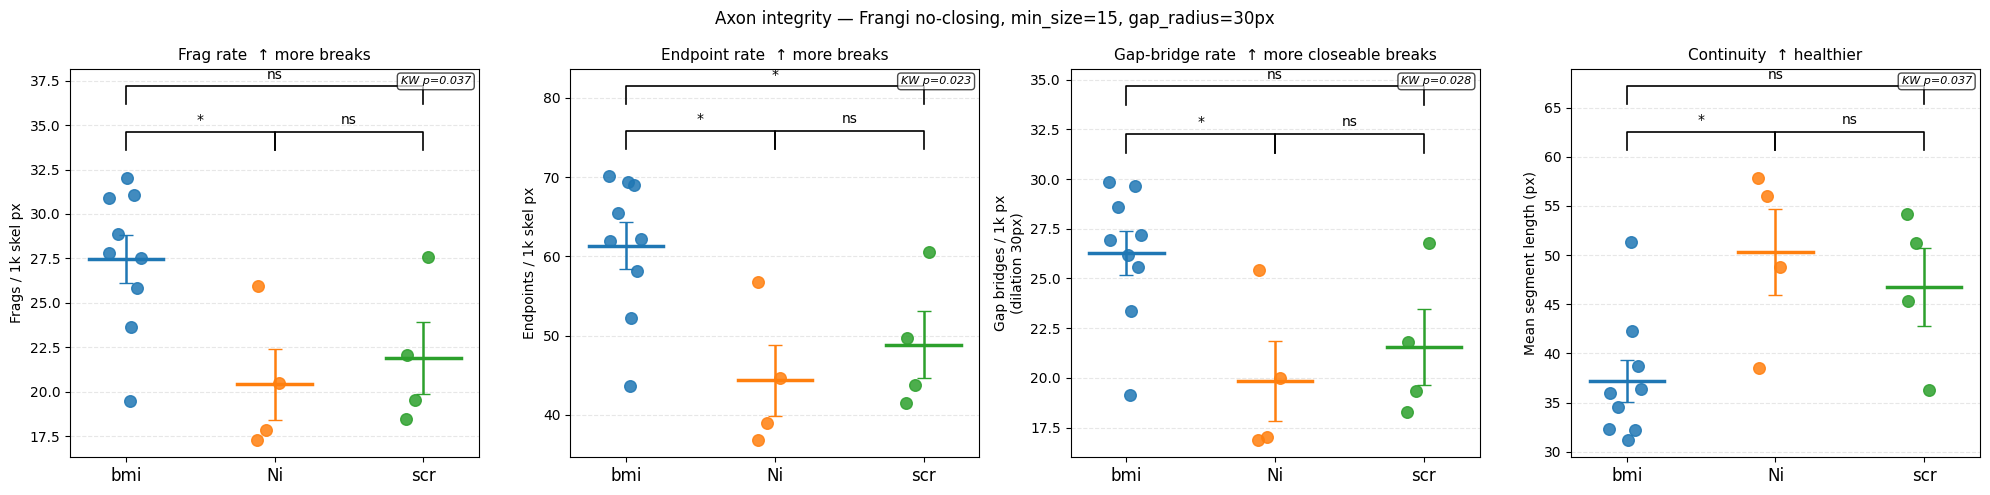

In [9]:
plot_comparison(
    directories={"bmi": directory_1, "Ni": directory_2, "scr": directory_3},
    gap_radius=30,
)

## Tuning guide

| Parameter | Default | Effect |
|-----------|---------|--------|
| `sigmas` | (1,2,3,4,5) | Axon width range Frangi detects. Extend upper end (e.g. `(1..8)`) if thick axon bundles are missed. |
| `min_component_size` | 15 | Minimum skeleton fragment to keep. Lower = more tiny stubs included. |
| `gap_radius` | 30 | Dilation radius for gap-bridge metric. Should match typical break gap size in pixels. |
| `max_gap` | 80 | Upper gap distance for break detection. Raise if breaks are wider. |
| `angle_threshold` | 40° | Max tangent deviation for a valid break pair. Lower = stricter. |